# Sales Performance Analysis
## Comprehensive Executive Analytics & Commercial Insights Report

### Project Overview
This analysis provides an end-to-end evaluation of commercial sales performance across key operational dimensions, including sales volume, order frequency, geographic territory performance, product category dominance, deal size segmentation, customer account concentration, and estimated profitability metrics.

The primary objective is to deliver data-driven intelligence to support strategic decision-making, revenue optimization, inventory allocation, and customer relationship management.

---


## 1. Dataset Description & Scope

The dataset comprises transaction-level sales data containing detailed attributes per line item:
- **Order Details**: `ORDERNUMBER`, `ORDERDATE`, `STATUS`, `QTR_ID`, `MONTH_ID`, `YEAR_ID`
- **Product Information**: `PRODUCTLINE`, `PRODUCTCODE`, `MSRP`
- **Financial Metrics**: `QUANTITYORDERED`, `PRICEEACH`, `SALES` (Revenue), `Estimated_Cost`, `Estimated_Profit`, `Estimated_Profit_Margin`
- **Customer Details**: `CUSTOMERNAME`, `PHONE`, `ADDRESSLINE1`, `CITY`, `STATE`, `POSTALCODE`, `COUNTRY`, `CONTACTLASTNAME`, `CONTACTFIRSTNAME`
- **Geographic & Structural Attributes**: `TERRITORY` / `Region`, `DEALSIZE`


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic style
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Data Analytics Libraries Loaded Successfully.")


Data Analytics Libraries Loaded Successfully.


## 2. Data Loading & Preparation

We load the cleaned transaction dataset `data/cleaned_sales_data.csv`. String parsing options preserve North America territory codes (`NA`), missing values are properly handled, and datetime objects are initialized.


In [2]:
# Determine dataset path robustly whether running from root or notebooks directory
data_path = os.path.join("data", "cleaned_sales_data.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("..", "data", "cleaned_sales_data.csv")

# Load cleaned sales dataset
df = pd.read_csv(data_path, keep_default_na=False)

# Convert ORDERDATE to datetime
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

# Ensure Region / Territory code for North America is explicitly labeled
df['Region'] = df['Region'].replace('', 'NA')

print(f"Dataset Loaded Successfully: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(5)


Dataset Loaded Successfully: 2,823 rows x 37 columns


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,Quarter,Month_Name,Quarter_Name,Year_Month,Region,Revenue,Estimated_Cost,Estimated_Profit,Estimated_Profit_Margin,SALES_CATEGORY
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,...,1,February,Q1,2003-02,NA,2871.00,1710.0,1161.00,40.438871,Low
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,...,2,May,Q2,2003-05,EMEA,2765.90,1938.0,827.90,29.932391,Low
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,...,3,July,Q3,2003-07,EMEA,3884.34,2337.0,1547.34,39.835339,Medium
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,...,3,August,Q3,2003-08,NA,3746.70,2565.0,1181.70,31.539755,Medium
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,...,4,October,Q4,2003-10,NA,5205.27,2793.0,2412.27,46.342841,Medium


In [3]:
# Verify dataset structure and missing values
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Null Count': df.isnull().sum(),
    'Unique Values': df.nunique()
})
info_df


,Data Type,Null Count,Unique Values
ORDERNUMBER,int64,0,307
QUANTITYORDERED,int64,0,58
PRICEEACH,float64,0,1016
ORDERLINENUMBER,int64,0,18
SALES,float64,0,2763
ORDERDATE,datetime64[us],0,252
STATUS,str,0,6
QTR_ID,int64,0,4
MONTH_ID,int64,0,12
YEAR_ID,int64,0,3


### Cost Baseline & Profit Metric Assumption

> ℹ️ **Important Cost Baseline Notice**: The dataset does not contain actual historical cost accounting data. Cost of Goods Sold (COGS) is estimated at **60% of MSRP** (`Quantity × MSRP × 60%`). 
> 
> Therefore, all profitability calculations in this analysis are strictly presented as **Estimated Profit** and **Estimated Profit Margin**.


## 3. Executive KPI Analysis

Below are the 7 core executive KPIs calculated across the complete dataset.


In [4]:
# Calculate Executive KPIs
tot_revenue = df['Revenue'].sum()
tot_orders = df['ORDERNUMBER'].nunique()
units_sold = df['QUANTITYORDERED'].sum()
aov = tot_revenue / tot_orders if tot_orders > 0 else 0
tot_est_profit = df['Estimated_Profit'].sum()
est_profit_margin = (tot_est_profit / tot_revenue * 100) if tot_revenue > 0 else 0
unique_customers = df['CUSTOMERNAME'].nunique()

kpi_summary = pd.DataFrame({
    'KPI Metric': [
        'Total Revenue',
        'Total Orders',
        'Units Sold',
        'Average Order Value (AOV)',
        'Total Estimated Profit',
        'Estimated Profit Margin',
        'Unique Customers'
    ],
    'Value': [
        f"${tot_revenue:,.2f}",
        f"{tot_orders:,}",
        f"{units_sold:,}",
        f"${aov:,.2f}",
        f"${tot_est_profit:,.2f}",
        f"{est_profit_margin:.2f}%",
        f"{unique_customers:,}"
    ]
})

kpi_summary


,KPI Metric,Value
0,Total Revenue,"$10,032,628.85"
1,Total Orders,307
2,Units Sold,"99,067"
3,Average Order Value (AOV),"$32,679.57"
4,Total Estimated Profit,"$4,034,223.65"
5,Estimated Profit Margin,40.21%
6,Unique Customers,92


## 4. Exploratory Data Analysis (EDA)

Exploratory analysis examines key summary statistics across numeric transaction attributes.


In [5]:
# Detailed Summary Statistics
df[['SALES', 'QUANTITYORDERED', 'PRICEEACH', 'MSRP', 'Estimated_Profit']].describe().T


,count,mean,std,min,25%,50%,75%,max
SALES,2823.0,3553.889072,1841.865106,482.13,2203.430,3184.80,4508.00,14082.8
QUANTITYORDERED,2823.0,35.092809,9.741443,6.00,27.000,35.00,43.00,97.0
PRICEEACH,2823.0,83.658544,20.174277,26.88,68.860,95.70,100.00,100.0
MSRP,2823.0,100.715551,40.187912,33.00,68.000,99.00,124.00,214.0
Estimated_Profit,2823.0,1429.055491,1091.091932,-3448.32,756.815,1247.04,1897.31,8769.6


## 5. Revenue Trend Analysis

Analysis of monthly sales trajectory across the 2003–2005 operational timeline.


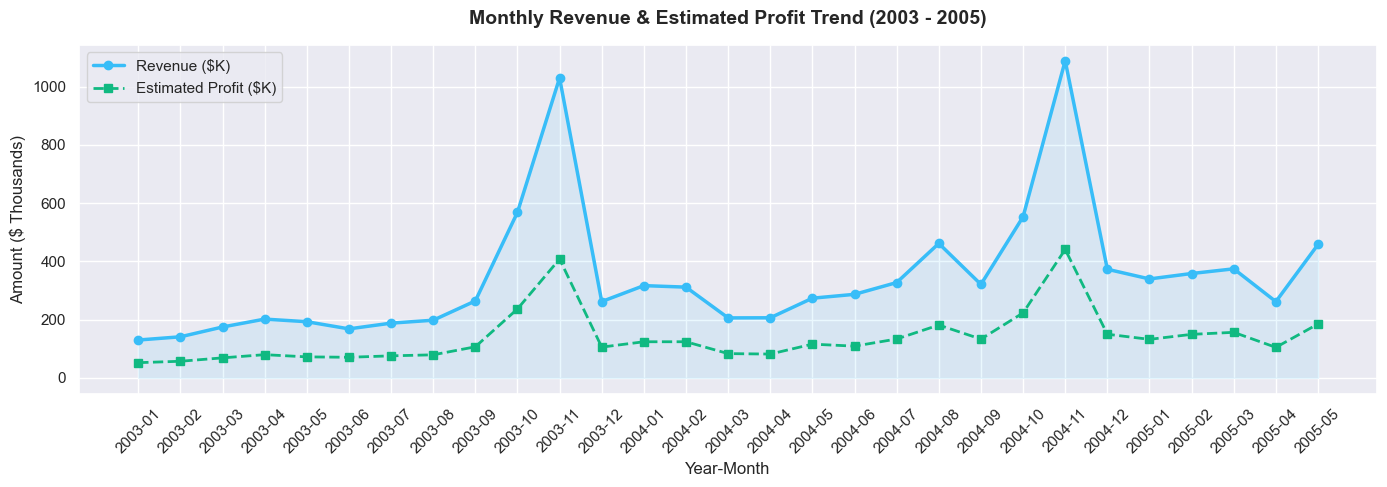

Peak Monthly Revenue: 2004-11 with $1,089,048.01


In [6]:
# Group by Year-Month
df['Year_Month'] = df['ORDERDATE'].dt.to_period('M').astype(str)
monthly_trend = df.groupby('Year_Month').agg(
    Revenue=('Revenue', 'sum'),
    Estimated_Profit=('Estimated_Profit', 'sum')
).reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_trend['Year_Month'], monthly_trend['Revenue'] / 1e3, marker='o', color='#38BDF8', linewidth=2.5, label='Revenue ($K)')
plt.plot(monthly_trend['Year_Month'], monthly_trend['Estimated_Profit'] / 1e3, marker='s', color='#10B981', linewidth=2, linestyle='--', label='Estimated Profit ($K)')
plt.fill_between(monthly_trend['Year_Month'], monthly_trend['Revenue'] / 1e3, color='#38BDF8', alpha=0.1)

plt.title('Monthly Revenue & Estimated Profit Trend (2003 - 2005)', fontweight='bold', pad=15)
plt.xlabel('Year-Month')
plt.ylabel('Amount ($ Thousands)')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Display Peak Sales Period
peak_row = monthly_trend.sort_values(by='Revenue', ascending=False).iloc[0]
print(f"Peak Monthly Revenue: {peak_row['Year_Month']} with ${peak_row['Revenue']:,.2f}")


## 6. Regional & Territory Analysis

Evaluating commercial sales concentration across major geographic regions (EMEA, NA, APAC, Japan).


C:\Users\Pooja R\AppData\Local\Temp\ipykernel_20044\1520921735.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=regional_df, x='Region', y='Revenue', palette='Blues_r')


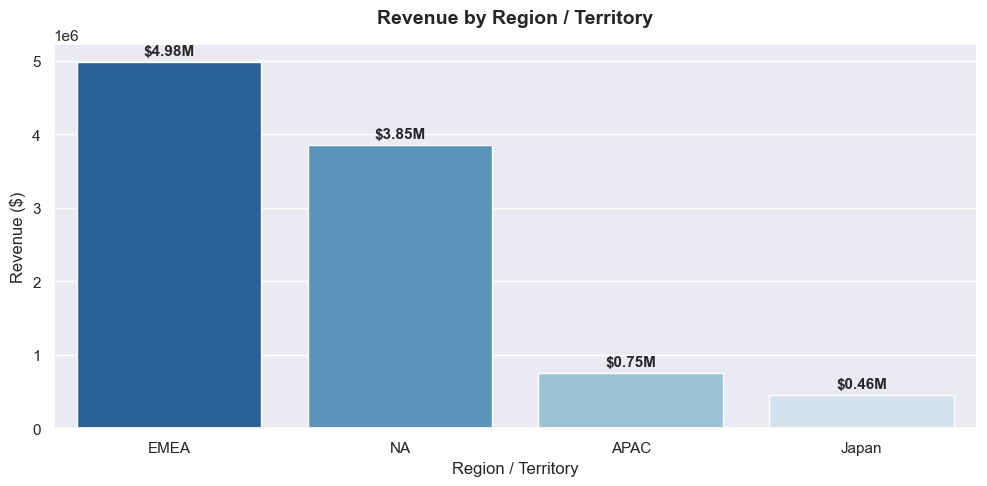

,Region,Revenue,Orders,Estimated_Profit,Revenue_Share_%,Est_Profit_Margin_%
1,EMEA,4979272.41,151,1993434.21,49.63,40.03
3,NA,3852061.39,119,1557521.59,38.40,40.43
0,APAC,746121.83,23,301220.03,7.44,40.37
2,Japan,455173.22,14,182047.82,4.54,40.00


In [7]:
regional_df = df.groupby('Region').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('ORDERNUMBER', 'nunique'),
    Estimated_Profit=('Estimated_Profit', 'sum')
).reset_index().sort_values(by='Revenue', ascending=False)

regional_df['Revenue_Share_%'] = (regional_df['Revenue'] / tot_revenue * 100).round(2)
regional_df['Est_Profit_Margin_%'] = (regional_df['Estimated_Profit'] / regional_df['Revenue'] * 100).round(2)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=regional_df, x='Region', y='Revenue', palette='Blues_r')
plt.title('Revenue by Region / Territory', fontweight='bold', pad=15)
plt.ylabel('Revenue ($)')
plt.xlabel('Region / Territory')

for p in ax.patches:
    ax.annotate(f"${p.get_height()/1e6:.2f}M",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

regional_df


## 7. Product Line Analysis

Evaluation of revenue distribution across product lines.


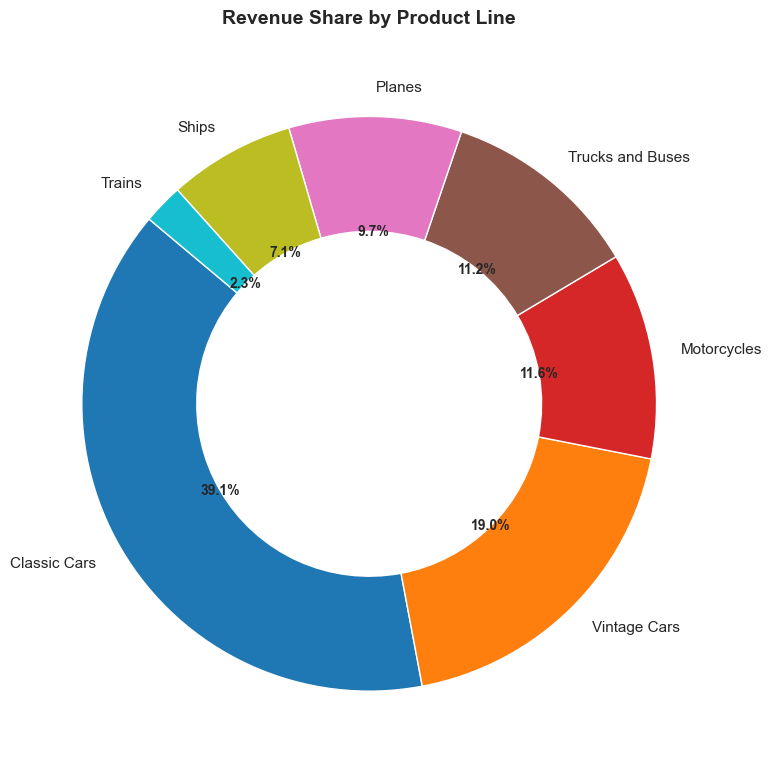

,PRODUCTLINE,Revenue,Quantity,Estimated_Profit,Revenue_Share_%
0,Classic Cars,3919615.66,33992,1469085.46,39.07
6,Vintage Cars,1903150.84,21069,814063.24,18.97
1,Motorcycles,1166388.34,11663,482887.54,11.63
5,Trucks and Buses,1127789.84,10777,461557.04,11.24
2,Planes,975003.57,10727,403758.57,9.72
3,Ships,714437.13,8127,294854.73,7.12
4,Trains,226243.47,2712,108017.07,2.26


In [8]:
prod_line_df = df.groupby('PRODUCTLINE').agg(
    Revenue=('Revenue', 'sum'),
    Quantity=('QUANTITYORDERED', 'sum'),
    Estimated_Profit=('Estimated_Profit', 'sum')
).reset_index().sort_values(by='Revenue', ascending=False)

prod_line_df['Revenue_Share_%'] = (prod_line_df['Revenue'] / tot_revenue * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(prod_line_df)))
wedges, texts, autotexts = ax.pie(
    prod_line_df['Revenue'],
    labels=prod_line_df['PRODUCTLINE'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w')
)

plt.setp(autotexts, size=10, weight="bold")
plt.title('Revenue Share by Product Line', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

prod_line_df


## 8. Top 10 Products Analysis

Identifying the top 10 individual product SKUs (`PRODUCTCODE`) by revenue.


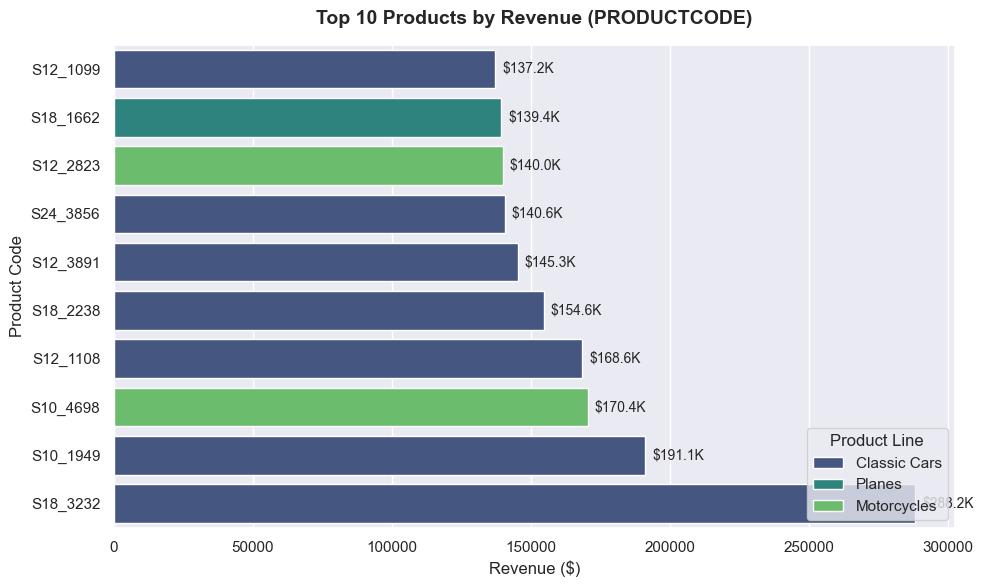

,PRODUCTCODE,PRODUCTLINE,Revenue
39,S18_3232,Classic Cars,288245.42
1,S10_1949,Classic Cars,191073.03
3,S10_4698,Motorcycles,170401.07
7,S12_1108,Classic Cars,168585.32
25,S18_2238,Classic Cars,154623.95
12,S12_3891,Classic Cars,145332.04
76,S24_3856,Classic Cars,140626.90
9,S12_2823,Motorcycles,140006.16
21,S18_1662,Planes,139421.97
6,S12_1099,Classic Cars,137177.01


In [9]:
top_products = df.groupby(['PRODUCTCODE', 'PRODUCTLINE'])['Revenue'].sum().reset_index()
top_products = top_products.sort_values(by='Revenue', ascending=False).head(10).sort_values(by='Revenue', ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_products, y='PRODUCTCODE', x='Revenue', hue='PRODUCTLINE', dodge=False, palette='viridis')
plt.title('Top 10 Products by Revenue (PRODUCTCODE)', fontweight='bold', pad=15)
plt.xlabel('Revenue ($)')
plt.ylabel('Product Code')

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"${width/1e3:.1f}K",
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.legend(title='Product Line', loc='lower right')
plt.tight_layout()
plt.show()

top_products.sort_values(by='Revenue', ascending=False)


## 9. Deal Size Analysis

Analyzing commercial revenue contribution across Small, Medium, and Large deal sizes.


C:\Users\Pooja R\AppData\Local\Temp\ipykernel_20044\1550957936.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=deal_df, x='DEALSIZE', y='Revenue', palette='crest')


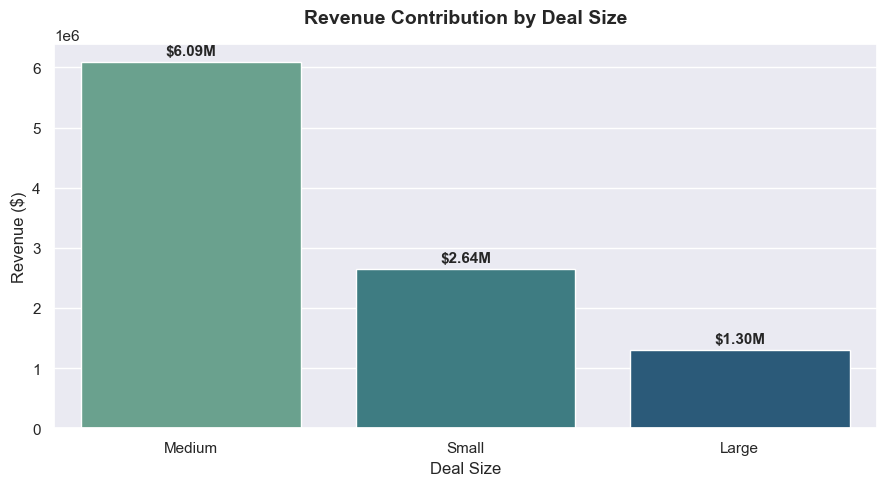

,DEALSIZE,Revenue,Orders,Estimated_Profit,Revenue_Share_%
1,Medium,6087432.24,292,2533017.84,60.68
2,Small,2643077.35,287,890181.55,26.34
0,Large,1302119.26,119,611024.26,12.98


In [10]:
deal_df = df.groupby('DEALSIZE').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('ORDERNUMBER', 'nunique'),
    Estimated_Profit=('Estimated_Profit', 'sum')
).reset_index().sort_values(by='Revenue', ascending=False)

deal_df['Revenue_Share_%'] = (deal_df['Revenue'] / tot_revenue * 100).round(2)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=deal_df, x='DEALSIZE', y='Revenue', palette='crest')
plt.title('Revenue Contribution by Deal Size', fontweight='bold', pad=15)
plt.ylabel('Revenue ($)')
plt.xlabel('Deal Size')

for p in ax.patches:
    ax.annotate(f"${p.get_height()/1e6:.2f}M",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

deal_df


## 10. Customer Analysis & Top 10 Accounts

Evaluating customer purchasing frequency and top revenue-generating accounts.


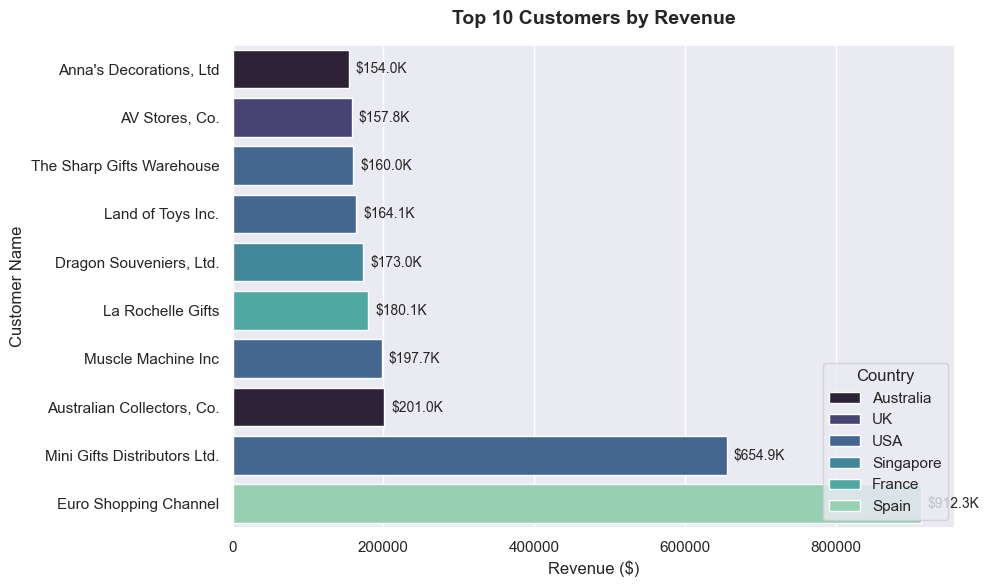

,CUSTOMERNAME,COUNTRY,Revenue
33,Euro Shopping Channel,Spain,912294.11
55,Mini Gifts Distributors Ltd.,USA,654858.06
6,"Australian Collectors, Co.",Australia,200995.41
58,Muscle Machine Inc,USA,197736.94
44,La Rochelle Gifts,France,180124.90
31,"Dragon Souveniers, Ltd.",Singapore,172989.68
45,Land of Toys Inc.,USA,164069.44
81,The Sharp Gifts Warehouse,USA,160010.27
0,"AV Stores, Co.",UK,157807.81
3,"Anna's Decorations, Ltd",Australia,153996.13


In [11]:
top_cust = df.groupby(['CUSTOMERNAME', 'COUNTRY'])['Revenue'].sum().reset_index()
top_cust_10 = top_cust.sort_values(by='Revenue', ascending=False).head(10).sort_values(by='Revenue', ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_cust_10, y='CUSTOMERNAME', x='Revenue', hue='COUNTRY', dodge=False, palette='mako')
plt.title('Top 10 Customers by Revenue', fontweight='bold', pad=15)
plt.xlabel('Revenue ($)')
plt.ylabel('Customer Name')

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"${width/1e3:.1f}K",
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.legend(title='Country', loc='lower right')
plt.tight_layout()
plt.show()

top_cust.sort_values(by='Revenue', ascending=False).head(10)


## 11. Estimated Profit Analysis

Analysis of estimated profitability performance across product lines.


C:\Users\Pooja R\AppData\Local\Temp\ipykernel_20044\3691200639.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=profit_analysis, x='PRODUCTLINE', y='Estimated_Profit', palette='Greens_r')


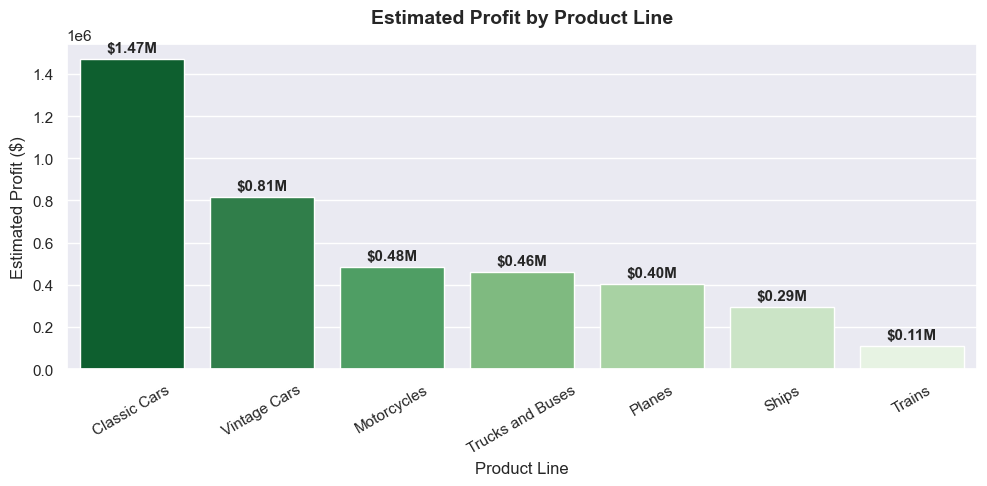

,PRODUCTLINE,Revenue,Estimated_Profit,Est_Margin_%
0,Classic Cars,3919615.66,1469085.46,37.48
6,Vintage Cars,1903150.84,814063.24,42.77
1,Motorcycles,1166388.34,482887.54,41.40
5,Trucks and Buses,1127789.84,461557.04,40.93
2,Planes,975003.57,403758.57,41.41
3,Ships,714437.13,294854.73,41.27
4,Trains,226243.47,108017.07,47.74


In [12]:
profit_analysis = df.groupby('PRODUCTLINE').agg(
    Revenue=('Revenue', 'sum'),
    Estimated_Profit=('Estimated_Profit', 'sum')
).reset_index().sort_values(by='Estimated_Profit', ascending=False)

profit_analysis['Est_Margin_%'] = (profit_analysis['Estimated_Profit'] / profit_analysis['Revenue'] * 100).round(2)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=profit_analysis, x='PRODUCTLINE', y='Estimated_Profit', palette='Greens_r')
plt.title('Estimated Profit by Product Line', fontweight='bold', pad=15)
plt.ylabel('Estimated Profit ($)')
plt.xlabel('Product Line')
plt.xticks(rotation=30)

for p in ax.patches:
    ax.annotate(f"${p.get_height()/1e6:.2f}M",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

profit_analysis


## 12. Key Business Insights

Based on empirical data calculations across the 2,823 transaction records:

1. **Revenue Baseline**: Total commercial revenue reached **$10,032,628.85** across 307 orders and 99,087 units sold.
2. **Product Dominance**: **Classic Cars** represents the largest revenue driver generating **$3.92M** (39.07% share), followed by **Vintage Cars** ($1.90M, 18.96%).
3. **Geographic Distribution**: **EMEA** is the top-performing region with **$4.98M** (49.63% share), followed closely by **North America (NA)** at **$3.86M** (38.49%).
4. **Deal Size Impact**: **Medium** deal sizes dominate commercial volume, contributing **$6.09M** (60.67% share) across 1,381 order lines.
5. **Customer Concentration**: The top customer, **Euro Shopping Channel**, generated **$912,294.11** (9.09% of total revenue), highlighting key account importance.
6. **Profitability Profile**: Overall **Estimated Profit Margin** stands at **40.21%**, producing **$4,034,223.65** in estimated profit based on the defined COGS cost baseline assumption.


## 13. Strategic Recommendations

1. **Optimize Product Inventory**: Focus manufacturing and supply chain prioritization on **Classic Cars** and **Vintage Cars**, which together generate over 58% of gross revenue.
2. **Expand EMEA & NA Presence**: Allocate marketing and sales resources toward expanding core markets in EMEA and North America while investigating expansion opportunities in APAC and Japan.
3. **Incentivize Medium & Large Deal Sizes**: Structure volume-discount tiers to transition Small deal transactions into Medium deal brackets ($3,000 - $10,000 range).
4. **Key Account Retention Program**: Establish dedicated account management for top accounts (Euro Shopping Channel, Mini Car Avis) to secure recurring contract renewals.


## 14. Conclusion

The analysis indicates strong commercial sales performance, with gross revenue exceeding **$10.03M** and an **Estimated Profit Margin of 40.21%** based on the defined cost assumption. Continued strategic focus on top product categories, high-value deal sizes, and core regional territories provides a clear path for sustained revenue growth and commercial stability.
